
<font size = "5"> **Day 3: [Spectroscopic Data & ML‑Enabled Analysis](../MLSTEM2026.ipynb)** </font>


<hr style="height:1px;border-top:4px solid #FF8200" />



[Download](https://github.com/gduscher/MLSTEM2026/raw/refs/heads/main/Day3/11AM_Analyse_EDS.ipynb)

[![OpenInColab](https://colab.research.google.com/assets/colab-badge.svg)](
   https://colab.research.google.com/github/gduscher/MLSTEM2026/blob/main/Day3/11AM_Analyse_EDS.ipynb)


# Analysis of EDS Spectra

part of the workshop of 

<font size = "5"> **[Machine Learning in Transmission Electron Microscopy](../MLSTEM2026.ipynb)**</font>


**Day3: Spectroscopic Data & ML‑Enabled Analysis**
<table style="margin-right:auto;margin-left:0px">
  <tr>
    <td>Gerd Duscher </td>
    <td>Sergei Kalinin</td>
  </tr>
  <tr>
    <td colspan="2"><center>Microscopy Facilities</td> 
  </tr>
  
  <tr>
    <td colspan="2"><center>Materials Science & Engineering</td>
    <td></td>
  </tr>
  <tr>
    <td colspan="2"><center>Institute of Advanced Materials & Manufacturing</td>
  </tr>
  <tr>
    <td colspan="2"><center> The University of Tennessee, Knoxville</center> </td>
  </tr>
</table>
        
**June 2026**


## Content
An Introduction into displaying and analyzing EDS spectrum images and spectra
This works also on Google Colab.


## Prerequesites

### Install pyTEMlib

If you have not done so in the [Introduction Notebook](_.ipynb), please test and install [pyTEMlib](https://github.com/gduscher/pyTEMlib) and other important packages with the code cell below.


In [ ]:
import sys
import importlib.metadata

def test_package(package_name):
    """Test if package exists and returns version or -1"""
    try:
        version = importlib.metadata.version(package_name)
    except importlib.metadata.PackageNotFoundError:
        version = '-1'
    return version


# pyTEMlib setup ------------------
if test_package('pyTEMlib') < '0.2026.6.0':
    print('installing pyTEMlib')
   
    !{sys.executable} -m pip install pyTEMlib --upgrade
# ------------------------------
print('done')

done


### Loading of necessary libraries

Please note, that we only need to load the pyTEMlib library, which is based on sidpy Datsets.



In [1]:
%matplotlib widget
import sys
import numpy as np
import matplotlib.pylab as plt

import pyTEMlib

if 'google.colab' in sys.modules:
    from google.colab import output
    output.enable_custom_widget_manager()
    from google.colab import drive

if 'google.colab' in sys.modules:
    drive.mount("/content/drive")

# For archiving reasons it is a good idea to print the version numbers out at this point
print('pyTEM version: ',pyTEMlib.__version__)
__notebook__ = 'EDS_Spectrum_Analysis'
__notebook_version__ = '2026_6_19'

pyTEM version:  0.2026.6.0


## Open File

### Load File

Select a main dataset and any additional data like reference data and such.

In [2]:
# C:\Users\gduscher\OneDrive - University of Tennessee\google_drive\2022 Experiments\Spectra\20221214\AlCe-200kV
fileWidget = pyTEMlib.file_tools.FileWidget('.')

### Select and Plot Dataset

Select a dataset from the drop down value and display it with the code cell below.

Here we sum the spectra of the 4 quadrants and define the detector parameter.

'c:\\Users\\gduscher\\Documents\\Github\\MLSTEM2026\\Day 3\\example_data\\EDS-STO.emd'

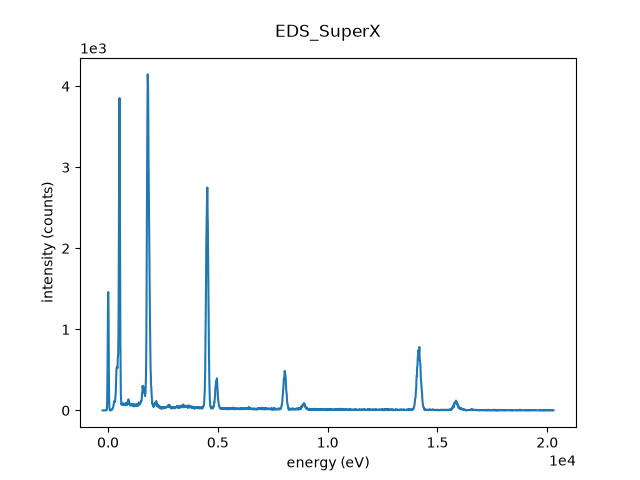

In [3]:
plt.close('all')
spectrum = fileWidget.selected_dataset
view = spectrum.plot()
spectrum.metadata['filename']


In [4]:
### Does not work for spectrum images

detector_Efficiency= pyTEMlib.eds_tools.detector_response(spectrum)  # tags, spectrum.energy_scale.values[start:])

spectrum.metadata['EDS']['detector'].setdefault('start_energy',  1)
spectrum.metadata['EDS']['detector']['start_channel'] = np.searchsorted(spectrum.energy_scale.values, spectrum.metadata['EDS']['detector']['start_energy'])
start = spectrum.metadata['EDS']['detector']['start_channel']
spectrum[:spectrum.metadata['EDS']['detector']['start_channel']] = 0.

spectrum.metadata['EDS']['detector']['detector_efficiency']  = detector_Efficiency

## Find Elements 
The minimum_number_of_peaks determines how many elements will be found. 

Increase from 10 to 11 of that parameter will reveal Nb a common dopant of SrTiO$_3$

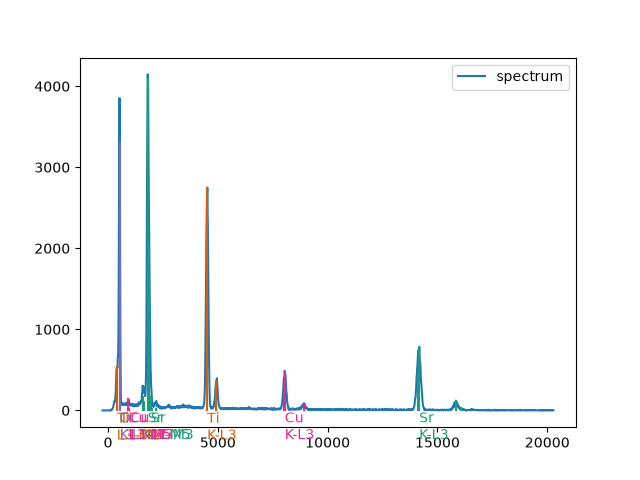

In [6]:

#element_dict = pyTEMlib.eds_tools.get_elements(spectrum) 
pyTEMlib.eds_tools.add_element(spectrum, ['Sr', 'Ti', 'O', 'Cu'])
spectrum.metadata['EDS']['elements'].keys()

plt.figure()
plt.plot(spectrum.energy_scale.values,spectrum, label = 'spectrum')
pyTEMlib.eds_tools.plot_lines(spectrum.metadata['EDS']['elements'], plt.gca())
plt.legend();

## Quantify

### Fit spectrum

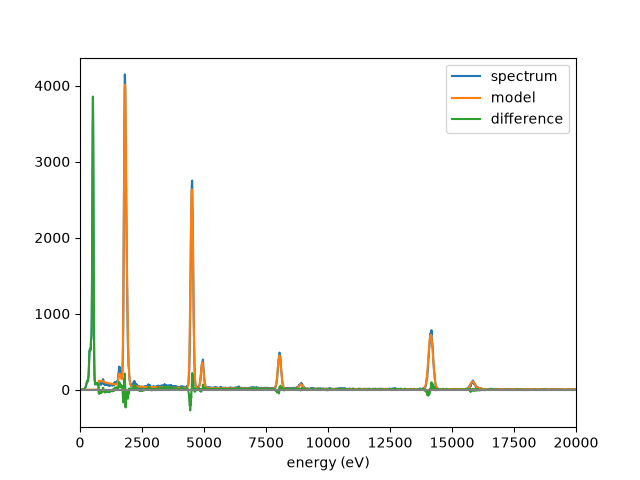

In [7]:
peaks, pp = pyTEMlib.eds_tools.fit_model(spectrum, use_detector_efficiency=True)
model = pyTEMlib.eds_tools.get_model(spectrum)

plt.figure()
plt.plot(spectrum.energy_scale.values, spectrum, label='spectrum')
plt.plot(spectrum.energy_scale.values, model, label='model')
plt.plot(spectrum.energy_scale.values, np.array(spectrum)-np.array(model), label='difference')
plt.xlabel('energy (eV)')
pyTEMlib.eds_tools.plot_lines(spectrum.metadata['EDS'], plt.gca())
plt.axhline(y=0, xmin=0, xmax=1, color='gray')
plt.legend()
plt.xlim(0,20000);

### Quantify Spectrum
first with Bote-Salvat cross section
using dictionaries calculated with [emtables package](https://github.com/adriente/emtables/blob/main/).

In [8]:
pyTEMlib.eds_tools.quantify_eds(spectrum, mask =['Cu'])

using cross sections for quantification
Sr: 23.36 at% 47.52 wt%
Ti: 32.43 at% 36.05 wt%
O : 44.21 at% 16.43 wt%


then with k-factor dictionary

In [9]:
q_dict = pyTEMlib.eds_tools.load_k_factors()
tags = pyTEMlib.eds_tools.quantify_eds(spectrum, q_dict, mask = ['Cu'])

using k-factors for quantification
Sr: 25.16 at% 52.11 wt%
Ti: 26.01 at% 29.43 wt%
O : 48.82 at% 18.46 wt%
Cu: 0.00 at% 0.00 wt%
excluded from quantification  ['Cu']


### Absorption Correction
Lower energy lines will be more affected than higher x-ray lines.

At thin sample location (<50nm) absorption is not significant.

In [15]:
# ------ Input ----------
thickness_in_nm = 190
# -----------------------
pyTEMlib.eds_tools.apply_absorption_correction(spectrum, thickness_in_nm)
for key, value in spectrum.metadata['EDS']['elements'].items():
    if 'corrected-atom%' in value:
        print(f"Element: {key}, Corrected Atom%: {value['corrected-atom%']:.2f}, Corrected Weight%: {value['corrected-weight%']:.2f}")

no symmetry
Element: Sr, Corrected Atom%: 19.92, Corrected Weight%: 47.34
Element: Ti, Corrected Atom%: 20.72, Corrected Weight%: 26.91
Element: O, Corrected Atom%: 59.36, Corrected Weight%: 25.75
Element: Cu, Corrected Atom%: 0.00, Corrected Weight%: 0.00


In [62]:
spectrum.metadata['EDS']['elements']['Sr']['symmetry']

'K-family'

## Summary
The spectrum is modeled completely with background and characteristic peak-families.

Either 
- k-factors in a file (here from Spectra300) or
- Bothe-Salvat cross-sections
 
are used for quantification.

## Appendix
### Background
The determined background used for the model-based quantification is based on the detector effciency.

Note:

The detector efficiency is also used for the quantification model.
